In [36]:
import numpy as np
import time
from pynq import MMIO, allocate, Overlay
import requests

In [37]:
ol = Overlay("base40.bit")

In [38]:
#base addresses
PIXEL_GEN_BASE  = 0x40000000
DMA_BASE = 0x40400000

#FPGA ----frame ----> AXI-Stream ----write----> DMA
# ┌─────────────────┬────────┬─────────────────────────────────────────────────┐
# │ Name            │ Offset │ Purpose                                         │
# ├─────────────────┼────────┼─────────────────────────────────────────────────┤
# │ S2MM_DMACR      │  0x30  │ Control Register — tells the DMA how to behave  │
# │ S2MM_DMASR      │  0x34  │ Status Register  — reflects DMA state / errors  │
# │ S2MM_DA         │  0x48  │ Destination Address — where in RAM to write data│
# │ S2MM_LENGTH     │  0x58  │ Transfer length (bytes) — writing this STARTS   │
# │                 │        │ the transfer; DMA then waits for stream data    │
# └─────────────────┴────────┴─────────────────────────────────────────────────┘
#
# ── S2MM_DMACR (0x30) — Control Register ──────────────────────────────────────
#   bit  0   RS          Run/Stop.  1 = channel running, 0 = channel stopped/halted.
#                        Must be set to 1 before writing S2MM_LENGTH.
#   bit  2   Reset       Soft-reset the S2MM channel.  Write 1; hardware self-clears
#                        within a few microseconds.  Clears all state from prior transfers.
#   bit 12   IOC_IrqEn   Enable "interrupt on completion" (IOC).  When the transfer
#                        finishes, IOC_Irq (DMASR bit 12) is set.
#   [23:16]  IRQThreshold  Number of completions before the interrupt fires.
#                        Set to 1 so every single transfer raises an interrupt.
#
# ── S2MM_DMASR (0x34) — Status Register ───────────────────────────────────────
#   bit  0   Halted      1 when the channel is stopped (RS=0 or after an error).
#                        Should go to 0 shortly after writing RS=1.
#   bit  1   Idle        1 when no transfer is in progress.
#   bit  4   DMAIntErr   Internal error.  Most common cause: the byte count in
#                        S2MM_LENGTH doesn't match where the FPGA asserts TLAST
#                        on the AXI-Stream.  Check BUF_BYTES matches FPGA output.
#   bit  6   SGDecErr    Scatter-Gather descriptor decode error.  Only relevant in
#                        SG mode — if this fires in Simple mode, the DMA is
#                        misconfigured (set to SG in Vivado when it should be Simple).
#   bit  7   SGSlvErr    Scatter-Gather slave error (similar: SG mode only).
#   bit 12   IOC_Irq     Interrupt-on-Completion flag.  Hardware sets this when the
#                        transfer finishes normally.  Write-1-to-Clear (W1C).
#   bit 14   Err_Irq     Summary error interrupt.  Set whenever any error bit fires.
#                        W1C.
#
# ── S2MM_DA (0x48) — Destination Address ──────────────────────────────────────
#   The physical (device) RAM address the DMA writes incoming stream bytes into.
#   Must be a physically contiguous buffer — use pynq.allocate(), NOT a regular
#   numpy array (which can be fragmented across pages and unusable by the DMA).
#   Obtain the address with buf.device_address after allocation.
#
# ── S2MM_LENGTH (0x58) — Transfer Length ──────────────────────────────────────
#   How many bytes to receive from the AXI-Stream.  Writing this register is the
#   "go" signal — the DMA immediately arms itself and waits for stream data.
#   For correctness, always write DMACR and DA *before* writing LENGTH.

S2MM_DMACR  = 0x30
S2MM_DMASR  = 0x34
S2MM_DA     = 0x48
S2MM_LENGTH = 0x58

# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# FRAME DIMENSIONS
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════

W, H      = 160, 120
TOTAL_NUM_OF_PIXELS  = W * H
#1 byte of info per pixel
BUF_BYTES = TOTAL_NUM_OF_PIXELS

# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# Memory Mapped Input/Output
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# MMIO init of pixel_gen and dma
pg  = MMIO(PIXEL_GEN_BASE,  0x1000)
dma = MMIO(DMA_BASE, 0x10000)

# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# FIXED-POINT HELPERS
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
#converts input to 18 bit q4.14 implementation
def q(x):
    #mul by 2^14 and pass it through bitmap
    return int(x * 16384) & 0x3FFFF

def pgw(reg, val):
    #writes value to register. each reg is 32 bits wide so offset is reg id * 4
    pg.write(reg * 4, int(val))

def pgr(reg):
    #read from reg
    return pg.read(reg * 4)

# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# PHYSICS PARAMETER WRITER
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# AXI-Lite register map for pixel_generator_0:
#  Reg  0        control        start  (1 = start, 0 = hold)
#  Reg  1        x_min          x_min
#  Reg  2        y_min          y_min
#  Reg  3        dx             width per pixel x_range / W
#  Reg  4        dy             width per pixel y_range / H
#  Reg  5, 6     mag0 x, y      magnet 0 x, y
#  Reg  7, 8     mag1 x, y      magnet 1 x, y
#  Reg  9, 10    mag2 x, y      magnet 2 x, y
#  Reg 11        gamma          velocity damping coefficient
#  Reg 12        omega2         omega squared
#  Reg 13        h2             height squared
#  Reg 14        mu             magnetic strength coefficient
#  Reg 15        dt             simulation time step
#  Reg 16        r_settle^2     pendulum settling distance limit
#  Reg 17        v_settle       pendulum settling velocity limit
#  Reg 18        r_settle^2+h^2 precomputed term for nearest-magnet check
#  Reg 19        misc           [31:12] = n_magnets (3), [11:0] = max_steps (4000)

def write_physics_params(
    magnets,
    x_min,
    y_min,
    x_range,
    y_range,
    gamma,
    omega2,
    h2,
    mu,
    dt=0.01,
    r_settle=0.25,
    traj_px_id= 9680,
):
    #all floats are translated to q4.14
    #set to hold
    pgw(0, 0)

    pgw(1, q(x_min))
    pgw(2, q(y_min))
    pgw(3, q(x_range / W)) #dx
    pgw(4, q(y_range / H)) #dy

    if isinstance(magnets, dict):
        mag_list = list(magnets.values())
    else:
        mag_list = list(magnets)

    default_mags = [
        {'x':  1.0, 'y':  0.0  },
        {'x': -0.5, 'y':  0.8660254037844386},
        {'x': -0.5, 'y': -0.8660254037844386},
    ]
    while len(mag_list) < 3:
        mag_list.append(default_mags[len(mag_list)])

    pgw(5,  q(mag_list[0]['x']))
    pgw(6,  q(mag_list[0]['y']))
    pgw(7,  q(mag_list[1]['x']))
    pgw(8,  q(mag_list[1]['y']))
    pgw(9,  q(mag_list[2]['x']))
    pgw(10, q(mag_list[2]['y']))

    pgw(11, q(gamma))
    pgw(12, q(omega2))
    pgw(13, q(h2))
    pgw(14, q(mu))
    pgw(15, q(dt))

    pgw(16, q(r_settle ** 2))
    pgw(17, q(0.05))
    pgw(18, q(r_settle ** 2 + h2))
    pgw(19, (3 << 12) | 4000) # [31:12] = 3 magnets,  [11:0] = 4000 max steps

    pgw(21, traj_px_id) 


# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# DMA ARM
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
def arm_dma(phys_addr):
    #prepare the DMA channel to receive one frame from the FPGA
    
    #reset DMA DMACONTROL[2] = reset
    dma.write(S2MM_DMACR, 0x00000004)   # DMACR[2] = Reset

    #Poll until hardware clears reset bit
    t0 = time.time()
    while dma.read(S2MM_DMACR) & 0x4:
        if time.time() - t0 > 1.0:
            print("DMA RESET WAS NOT CLEARED")
            break
        time.sleep(0.001)

    #clears all error bits
    #writing 0x7000 clears all three error bits so we start with a clean status register.
    dma.write(S2MM_DMASR, 0x00007000)


    #channel config
    # 0x01001001 breakdown:
    # bit  0 = 1 -> Run/Stop = 1 -> start running channel
    # bit 12 = 1  -> IOC_IrqEn = 1 -> raise interrupt when complete
    # bits [23:16] = 1 ->  IRQThreshold =1 -> interrupt after 1 completion
    dma.write(S2MM_DMACR, 0x01001001)

    #set destination address to the buffer address
    dma.write(S2MM_DA, phys_addr)

    #write byte count
    dma.write(S2MM_LENGTH, BUF_BYTES)


# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# DMA POLL
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
def poll_dma(timeout=60.0):
    #polls for DMA channel to finish
    #returns tuple (done, elasped_seconds)
    #done=True  → IOC_Irq fired
    #done=False → timeout/error
    
    #read init
    
    t0      = time.time()
    sr_init = dma.read(S2MM_DMASR)

    while time.time() - t0 < timeout:
        sr  = dma.read(S2MM_DMASR)
        fdl = pgr(20) & 0x1   # pixel_generator frame_done_latch: 1 = FPGA finished its frame
        
        #success
        if (sr & 0x1000) and not (sr_init & 0x1000):
            return True, time.time() - t0

        #error code
        if sr & 0x4010:
            print("DMA ERROR")
            return False, time.time() - t0

        time.sleep(0.01) #10 ms poll interval -> possibly optimise?
        
    return False, timeout #timed out


# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# PIXEL BUFFER DECODING
# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
#DECODE MAP:
#  bits [1:0]  magnet_id  0 means timedout
#  bits [5:2]  step_cat   convergence categroy (0 = timed out, higher the number, faster the convergence)

def decode_buffer(raw):
    pixels   = np.array(raw[:TOTAL_NUM_OF_PIXELS], dtype=np.uint8)
    mag_id   = (pixels & 0x3).astype(np.uint8) #lower 2 bits = magent id 0x3 = 11
    step_cat = ((pixels >> 2) & 0xF).astype(np.uint8) #the other 4 bits  = step_cateogry

    #remap if needed:
    remap  = np.array([0, 1, 2, 3], dtype=np.uint8)
    mag_id = remap[mag_id]

    return pixels, mag_id, step_cat


def to_signed32(v):
    return v - (1 << 32) if (v & (1 << 31)) else v

def read_trajectory():
    n = pgr(27) # traj_write_addr
    if n == 0:
        return []
    xs = np.empty(n); ys = np.empty(n)
    for step in range(n):
        pgw(22, step)                # traj_rd_addr
        xs[step] = to_signed32(pgr(23)) / 16384.0   # Q4.14 to float
        ys[step] = to_signed32(pgr(24)) / 16384.0
    return list(zip(xs, ys))

In [39]:
def fetch_params():
    #fetch latest params
    resp = requests.get('http://35.179.111.223:5000/info', timeout=5)
    return resp.json()

def extract_params(data):
    #JSON unpacker to flat dict of values
    grid = data['physical_grid']
    x_min, x_max = grid['x_min'], grid['x_max']
    y_min, y_max = grid['y_min'], grid['y_max']
    L = data['pendulum_length']
    return {
        'magnets': data['magnets'],
        'x_min':   x_min,
        'x_max':   x_max,
        'y_min':   y_min,
        'y_max':   y_max,
        'x_range': x_max - x_min,
        'y_range': y_max - y_min,
        'mu':      data['magnetic_strength'],
        'gamma':   data['damping_factor'],
        'h2':      data['pendulum_height'] ** 2,
        'omega2':  9.81 / L if L>0 else 9.81, #fix
    }

# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# REFRESH STATE

last_params = None

POLL_INTERVAL = 0.1 #seconds between FLASK endpoint polls
#ALLOCATE DMA BUFFER
buf1 = allocate(shape=(BUF_BYTES,), dtype=np.uint8)

# ══════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════════
# POLL LOOP
while True:
    try:
        print("Polling Flask...")
        params = extract_params(fetch_params())

        if params != last_params:
            #change in param
            last_params = params

            #push updated values to FPGA
            write_physics_params(
                magnets = params['magnets'],
                x_min   = params['x_min'],
                y_min   = params['y_min'],
                x_range = params['x_range'],
                y_range = params['y_range'],
                gamma   = params['gamma'],
                omega2  = params['omega2'],
                h2      = params['h2'],
                mu      = params['mu'],
            )

            #arm dma
            arm_dma(buf1.device_address)

            #start FPGA computation
            pgw(0, 1)

            #poll dma
            done, elapsed = poll_dma()

            # trajectory debug
            r21 = pgr(21)        # traj_px_id readback (lane input)
            r27 = pgr(27)        # traj_wr_addr  (points captured so far)
            r25 = pgr(25)        # traj_len
            r26 = pgr(26) & 0x1  # traj_done_latch
            print(f"  reg21 traj_px_id readback = {r21}")
            print(f"  reg27 traj_wr_addr        = {r27}")
            print(f"  reg25 traj_len            = {r25}")
            print(f"  reg26 traj_done_latch     = {r26}")


            traj = read_trajectory()
            print(f"  Trajectory: {len(traj)} points")

            #stop fpga and flush CPU cache/buffer
            pgw(0, 0)
            buf1.invalidate()

            #decode raw buffer
            raw              = np.array(buf1, dtype=np.uint8)
            pixels, mag_id, cat = decode_buffer(raw)

            #repack for server and send to flask
            repacked = ((mag_id & 0x3) << 4) | (cat & 0xF)
            resp = requests.post(
                'http://35.179.111.223:5000/image',
                data=repacked.tobytes(),
                headers={"Content-Type": "application/octet-stream"},
            )
            print("  Status:", resp.status_code)
            

        time.sleep(POLL_INTERVAL)
    except KeyboardInterrupt:
        print("Polling stopped.")
        break
    except Exception as e:
        print(f"Error: {e}")
        time.sleep(POLL_INTERVAL)
        

Polling Flask...
  reg21 traj_px_id readback = 9680
  reg27 traj_wr_addr        = 4000
  reg25 traj_len            = 4000
  reg26 traj_done_latch     = 1
  Trajectory: 4000 points
  Status: 200
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling Flask...
Polling stopped.


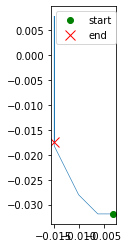

len(traj): 4000
first 5: [(-0.003173828125, -0.0318603515625), (-0.00323486328125, -0.0318603515625), (-0.0032958984375, -0.0318603515625), (-0.00335693359375, -0.0318603515625), (-0.00341796875, -0.0318603515625)]
last 5: [(-0.014892578125, -0.0174560546875), (-0.014892578125, -0.0174560546875), (-0.014892578125, -0.0174560546875), (-0.014892578125, -0.0174560546875), (-0.014892578125, -0.0174560546875)]
pixel  9680 raw: 3 mag_id: 3 step_cat: 0


In [40]:
import matplotlib.pyplot as plt
xs = [p[0] for p in traj]; ys = [p[1] for p in traj]
plt.plot(xs, ys, lw=0.6)
plt.plot(xs[0], ys[0], 'go', label='start')
plt.plot(xs[-1], ys[-1], 'rx', ms=10, label='end')
plt.gca().set_aspect('equal'); plt.legend(); plt.show()
print("len(traj):", len(traj))          # must equal 399
print("first 5:", traj[:5])
print("last 5:", traj[-5:])
traj_px_id = pgr(21)
print("pixel " , traj_px_id ,"raw:", raw[traj_px_id], "mag_id:", raw[traj_px_id] & 0x3, "step_cat:", (raw[traj_px_id]>>2)&0xF)

In [41]:
import numpy as np
mid = pixels & 0x3
cat = (pixels >> 2) & 0xF
timeout_idx = np.where((cat == 0))[0]
print("num timed-out pixels:", len(timeout_idx))
if len(timeout_idx):
    print("example IDs:", timeout_idx[:10])

num timed-out pixels: 1250
example IDs: [ 24  59  64  80 111 154 155 156 160 167]


In [42]:
import os
import numpy as np

buf = allocate(shape=(H * W,), dtype=np.uint8)

arm_dma(buf.device_address)      # instead of dma.recvchannel.transfer(buf)
pgw(0, 1)                        # start the FPGA
done, _ = poll_dma()             # instead of dma.recvchannel.wait()
assert done, "DMA didn't complete"
pgw(0, 0)                        # stop

buf.invalidate()
raw = np.array(buf, dtype=np.uint8).reshape(H, W)
labels_fpga = (raw & 0x3).astype(np.uint8)
steps = ((raw >> 2) & 0xF).astype(np.uint8)

np.save("fpga_labels_reference_style.npy", labels_fpga)
np.save("fpga_step_categories_reference_style.npy", steps)
print("Saved", os.path.abspath("fpga_labels_reference_style.npy"))
print("Shape:", labels_fpga.shape)
print("Unique labels:", np.unique(labels_fpga, return_counts=True))
print("Step categories:", np.unique(steps, return_counts=True))

Saved /home/xilinx/jupyter_notebooks/mag_pendulum/fpga_labels_reference_style.npy
Shape: (120, 160)
Unique labels: (array([1, 2, 3], dtype=uint8), array([6004, 6128, 7068]))
Step categories: (array([0, 1, 2, 3, 4, 5, 6, 7, 8], dtype=uint8), array([1250, 4843, 2165, 4068, 3640, 2617,  579,   37,    1]))


In [43]:
p = extract_params(fetch_params())
for name in ['omega2', 'gamma', 'mu', 'h2']:
    r = q(p[name])
    signed = r - (1 << 18) if (r & (1 << 17)) else r
    print(f"{name}: requested {p[name]:.4f}  →  FPGA sees {signed/16384:.4f}")

omega2: requested 0.9995  →  FPGA sees 0.9995
gamma: requested 0.1965  →  FPGA sees 0.1964
mu: requested 0.9922  →  FPGA sees 0.9921
h2: requested 0.2515  →  FPGA sees 0.2515


In [44]:
def capture():
    arm_dma(buf1.device_address); pgw(0, 1)
    done, _ = poll_dma(); assert done, "DMA didn't finish"
    pgw(0, 0); buf1.invalidate()
    return np.array(buf1, np.uint8).copy()

a = capture(); b = capture()
cat_a = (a >> 2) & 0xF
cat_b = (b >> 2) & 0xF
print("identical:", np.array_equal(a, b), "| differing pixels:", int((a != b).sum()))
print("timeouts a:", int((cat_a == 0).sum()), " timeouts b:", int((cat_b == 0).sum()))

identical: True | differing pixels: 0
timeouts a: 1250  timeouts b: 1250
